# Importing libraries

In [8]:
import sys
sys.executable


'c:\\Users\\borhe\\Desktop\\Fake News Detection\\ml approach\\venv\\Scripts\\python.exe'

In [2]:
import nltk
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\borhe\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\borhe\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\borhe\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\borhe\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [3]:
# Data manipulation
import pandas as pd     
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TF-IDF & bag-of-words
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer 

# Model Training Utilities
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb           
from sklearn.svm import SVC

# NLP libraries
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
stop_words = set(stopwords.words("english"))

# Ignore warnings for cleaner logs
import warnings
warnings.filterwarnings("ignore")         

# Reading the data

In [5]:
real = pd.read_csv('C:\\Users\\borhe\\Desktop\\Fake News Detection\\ml approach\\data\\True.csv')
fake = pd.read_csv('C:\\Users\\borhe\\Desktop\\Fake News Detection\\ml approach\\data\\Fake.csv')

real['label'] = 1
fake['label'] = 0

# Combine real and fake into one dataset
df = pd.concat([real, fake], ignore_index=True)
df = df.sample(frac=1).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Federal Judge Just Gave Attorney General Jeff...,A federal judge just proudly gave Jeff Session...,News,"April 7, 2017",0
1,Watch Elizabeth Warren Clobber Trump And Scot...,Massachusetts Senator Elizabeth Warren once ag...,News,"June 19, 2016",0
2,WATCH: VINTAGE JOHNNY CASH VIDEO Delivers A PO...,Out of all of the places we ve ever been over...,politics,"Oct 19, 2017",0
3,Saudi Shura Council to vote on curbing autonom...,RIYADH (Reuters) - Saudi Arabia s Shura Counci...,worldnews,"September 18, 2017",1
4,Millions to lose health insurance under Republ...,WASHINGTON (Reuters) - Millions of Americans w...,politicsNews,"March 13, 2017",1


# Exploring the data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


<Axes: xlabel='label', ylabel='count'>

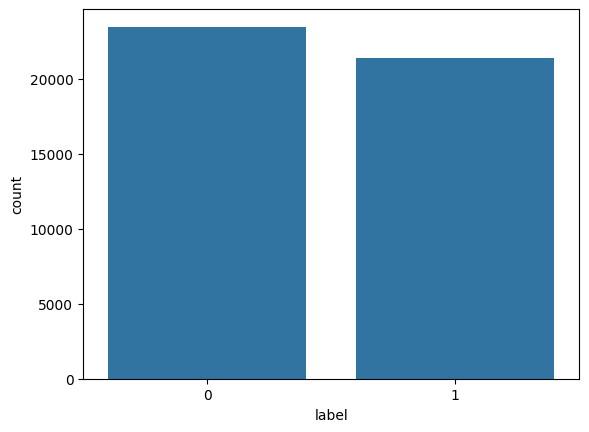

In [7]:
sns.countplot(data=df,
              x='label',
              order=df['label'].value_counts().index)

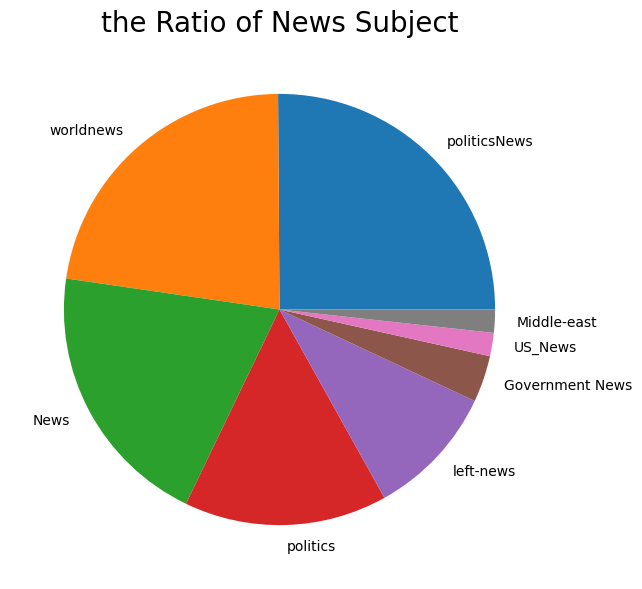

In [9]:
plt.figure(figsize=(7,7))
plt.pie(x = df['subject'].value_counts() ,labels=df['subject'].value_counts().index)
plt.title('the Ratio of News Subject',fontsize=20)
plt.show()

# Text preprocessing

In [10]:
def clean_text(text):
     # Remove Twitter handles starting with '@'
    text = re.sub(r'@\w+', '', text)
    
    # Remove non-alphanumeric characters and extra whitespace
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Convert multiple whitespace characters to a single space
    text = re.sub(r'\s+', ' ', text)
    
    # Convert the text to lowercase
    text = text.lower()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stop words
    tokens = [word for word in tokens if word not in stop_words]

     # Lemmatize tokens
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join back into a single string
    return " ".join(tokens)

In [11]:
df1 = df.copy()
df1['text'] = df1['text'].apply(clean_text)
df1

,title,text,subject,date,label
0,Federal Judge Just Gave Attorney General Jeff...,federal judge proudly gave jeff session middle...,News,"April 7, 2017",0
1,Watch Elizabeth Warren Clobber Trump And Scot...,massachusetts senator elizabeth warren took ai...,News,"June 19, 2016",0
2,WATCH: VINTAGE JOHNNY CASH VIDEO Delivers A PO...,place ever overseas place overseas matter ya k...,politics,"Oct 19, 2017",0
3,Saudi Shura Council to vote on curbing autonom...,riyadh reuters saudi arabia shura council infl...,worldnews,"September 18, 2017",1
4,Millions to lose health insurance under Republ...,washington reuters million american would lose...,politicsNews,"March 13, 2017",1
...,...,...,...,...,...
44893,Romania senate backs bill seen in West as thre...,bucharest reuters romania senate approved wedn...,worldnews,"December 20, 2017",1
44894,World Food Programme cuts rations for refugees...,nairobi reuters un world food programme cuttin...,worldnews,"October 2, 2017",1
44895,The FIVE Most Ridiculous Things Done So Far B...,last saturday bunch wellarmed militiaman decid...,News,"January 6, 2016",0
44896,Exclusive: Mexican leftist has 11-point lead a...,mexico city reuters mexican leftist andres man...,worldnews,"December 19, 2017",1


In [12]:
X = df1['text']
y = df1['label']

# Vectorization

In [13]:
# TF-Idf vectorizer

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

vectorizer = TfidfVectorizer(
    max_df=0.9,
    min_df=5,
    ngram_range=(1, 2)
)

X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

# Model training, Evaluation, and Prediction

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial NB": MultinomialNB(),
    "XGBoost": xgb.XGBClassifier(
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train 
    model.fit(X_train, y_train)
    
    # Train evaluation
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average="binary")
    
    # Test evaluation 
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average="binary")
    
    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Train F1": train_f1,
        "Test Accuracy": test_acc,
        "Test F1": test_f1
    })
    
    print(f"Train → Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"Test  → Acc: {test_acc:.4f} | F1: {test_f1:.4f}")



Training Logistic Regression...
Train → Acc: 0.9937 | F1: 0.9934
Test  → Acc: 0.9871 | F1: 0.9867

Training Multinomial NB...
Train → Acc: 0.9668 | F1: 0.9650
Test  → Acc: 0.9601 | F1: 0.9589

Training XGBoost...
Train → Acc: 1.0000 | F1: 1.0000
Test  → Acc: 0.9978 | F1: 0.9977

Training Random Forest...
Train → Acc: 1.0000 | F1: 1.0000
Test  → Acc: 0.9916 | F1: 0.9914


In [15]:
best_model = xgb.XGBClassifier(
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42
    )
best_model.fit(X_train, y_train) 
y_pred = model.predict(X_test) 
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4622
           1       0.99      0.99      0.99      4358

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



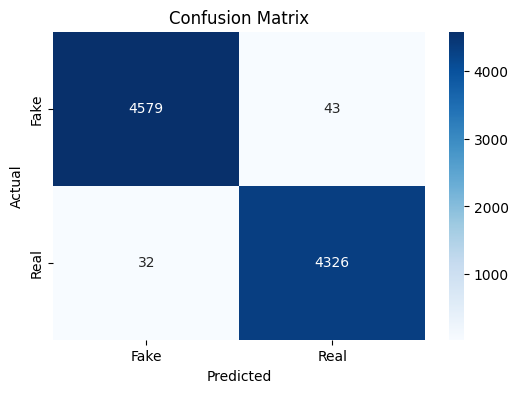

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Saving the model

In [18]:
import joblib

joblib.dump(best_model, "models/fake_news_model.pkl")
joblib.dump(vectorizer, "models/tfidf_vectorizer.pkl")

['models/tfidf_vectorizer.pkl']